In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RGate
from qiskit.converters import circuit_to_gate
from qutip import *
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from custom_gates import shors,state_generation
from qiskit.visualization import plot_histogram
from scipy.stats.contingency import margins
from qiskit.quantum_info import partial_trace

In [2]:
cutoff = 2**7
qmr1 = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))),name = 'qumode')
qbr = QuantumRegister(1)
cr = ClassicalRegister(1)

## GKP State

In [29]:
delta = 0.222

circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(delta),qmr1[0])  # qumode 0 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(delta),qmr1[1])  # qumode 1 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(delta),qmr1[2])  # qumode 2 in squeezed vaccum at x=0

N_rounds = 9
alpha = np.sqrt(np.pi) 

for k in range(1,N_rounds):
    circuit.cv_c_d(alpha,qmr1[0],qbr[0])
    Uxk = state_generation.Ux_operator(cutoff,alpha,4*k,delta)
    Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
    circuit.append(Ux_gate, qmr1[0] + qbr[:])

for k in range(1,N_rounds):
    circuit.cv_c_d(alpha,qmr1[1],qbr[0])
    Uxk = state_generation.Ux_operator(cutoff,alpha,4*k,delta)
    Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
    circuit.append(Ux_gate, qmr1[1] + qbr[:])

# circuit.measure(qbr[0],cr)
    
stateop, result, _ = c2qa.util.simulate(circuit,shots = 10)

In [104]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

0.017714833846943237


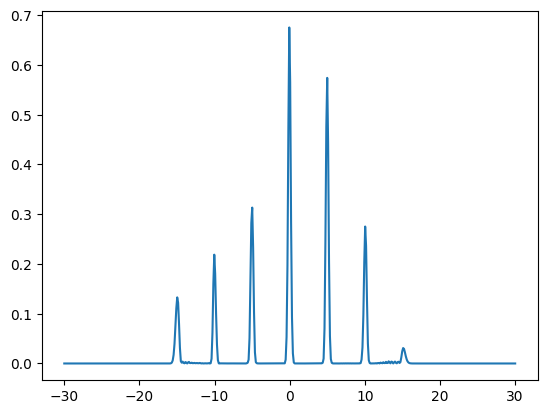

In [105]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff, ax_min=-30, ax_max=30)
display(plt.plot(xaxis,x_dist))

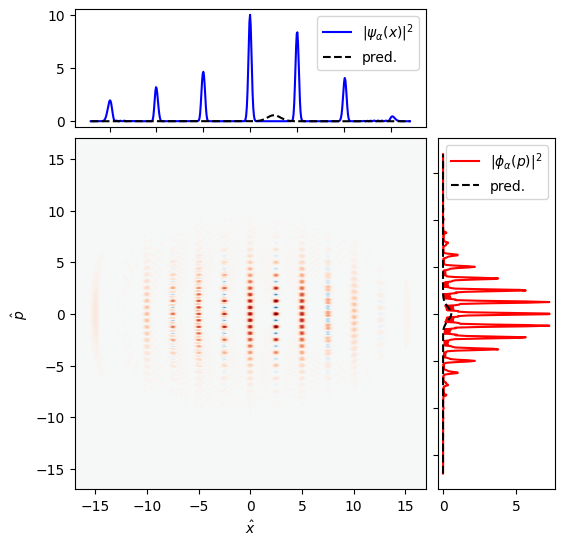

In [106]:
#This cell is mostly plotting
w = c2qa.wigner.wigner(rho_qumode_0, axes_max= 17, axes_min= -17, axes_steps = 500)
x_dist, y_dist = margins(w.T)

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(3, 1), height_ratios=(1, 3),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1,0])
ax_x = fig.add_subplot(gs[0,0])
ax_y = fig.add_subplot(gs[1,1])

absmax = max(np.max(w), np.abs(np.min(w)))
color_levels = np.linspace(-absmax, absmax, 100)

#Plot the wigner function of the coherent state in the main panel with a colormap
xaxis = np.linspace(-17, 17, 500)
yaxis = np.linspace(-17, 17, 500)
cont = ax.contourf(xaxis, yaxis, w, color_levels, cmap = "RdBu_r")

#compute the expected means and variance of the two distributions
mux = np.sqrt(2)*np.real(alpha)
muy = np.sqrt(2)*np.imag(alpha)
sigma = .5

#plot the distributions against the (normalized) marginals of the wigner function
ax_x.plot(xaxis, x_dist,  label = r"$|\psi_\alpha(x)|^2$", c= "b")
ax_x.plot(xaxis, 1/np.sqrt(2*np.pi*sigma)*np.exp(-(xaxis-mux)**2/(2*sigma)), c ="k", linestyle = "--", label="pred.")

ax_y.plot(y_dist.T, yaxis, label = r"$|\phi_\alpha(p)|^2$", c = "r")
ax_y.plot(1/np.sqrt(2*np.pi*sigma)*np.exp(-(yaxis-muy)**2/(2*sigma)), yaxis, c="k", linestyle = "--", label = "pred.")

ax.set(xlabel=r"$\hat x$", ylabel=r"$\hat p$")
ax_x.legend()
ax_y.legend()
ax_x.set_xticklabels([]);
ax_y.set_yticklabels([]);

## Translation of qumode 0

In [30]:
R_displace = shors.translation_R(cutoff,15)
gate1 =UnitaryGate(R_displace.full(), label='R')
circuit.append(gate1, qmr1[0])

stateop, result, _ = c2qa.util.simulate(circuit,shots = 10)

In [12]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

2.151584076592041


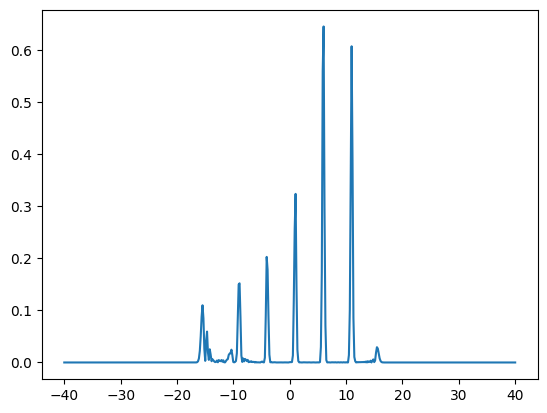

In [9]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff, ax_min=-40, ax_max=40)
display(plt.plot(xaxis,x_dist))

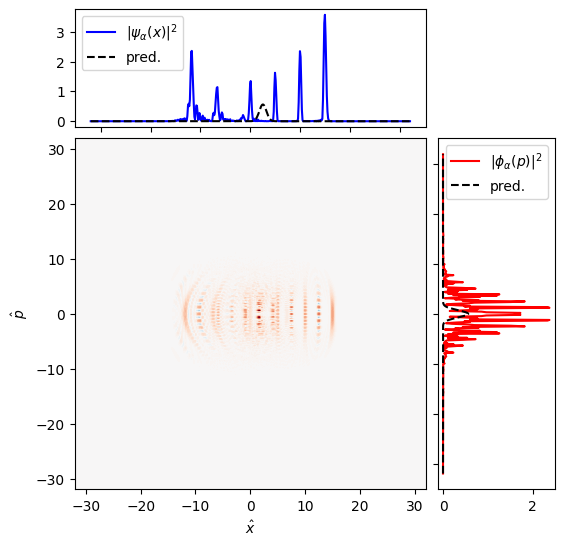

In [13]:
#This cell is mostly plotting
w = c2qa.wigner.wigner(rho_qumode_0, axes_max= 32, axes_min= -32, axes_steps = 500)
x_dist, y_dist = margins(w.T)

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(3, 1), height_ratios=(1, 3),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1,0])
ax_x = fig.add_subplot(gs[0,0])
ax_y = fig.add_subplot(gs[1,1])

absmax = max(np.max(w), np.abs(np.min(w)))
color_levels = np.linspace(-absmax, absmax, 100)

#Plot the wigner function of the coherent state in the main panel with a colormap
xaxis = np.linspace(-32, 32, 500)
yaxis = np.linspace(-32, 32, 500)
cont = ax.contourf(xaxis, yaxis, w, color_levels, cmap = "RdBu_r")

#compute the expected means and variance of the two distributions
mux = np.sqrt(2)*np.real(alpha)
muy = np.sqrt(2)*np.imag(alpha)
sigma = .5

#plot the distributions against the (normalized) marginals of the wigner function
ax_x.plot(xaxis, x_dist,  label = r"$|\psi_\alpha(x)|^2$", c= "b")
ax_x.plot(xaxis, 1/np.sqrt(2*np.pi*sigma)*np.exp(-(xaxis-mux)**2/(2*sigma)), c ="k", linestyle = "--", label="pred.")

ax_y.plot(y_dist.T, yaxis, label = r"$|\phi_\alpha(p)|^2$", c = "r")
ax_y.plot(1/np.sqrt(2*np.pi*sigma)*np.exp(-(yaxis-muy)**2/(2*sigma)), yaxis, c="k", linestyle = "--", label = "pred.")

ax.set(xlabel=r"$\hat x$", ylabel=r"$\hat p$")
ax_x.legend()
ax_y.legend()
ax_x.set_xticklabels([]);
ax_y.set_yticklabels([]);

## Multiply Qumode 1 with N

In [31]:
Malpha = shors.multiplication(cutoff,15)
gate2 =UnitaryGate(Malpha.full(), label='M15')
circuit.append(gate2, qmr1[1])

stateop, result, _ = c2qa.util.simulate(circuit,shots = 10)

In [15]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

0.5989051115297495


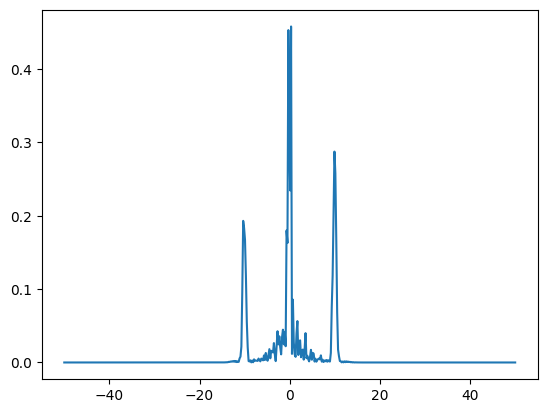

In [87]:
x_dist,xaxis = shors.position_plotting(rho_qumode_1,cutoff, ax_min=-50, ax_max=50)
display(plt.plot(xaxis,x_dist))

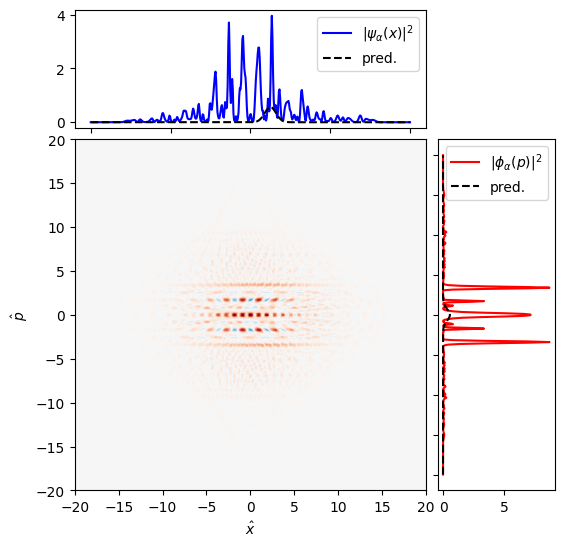

In [16]:
#This cell is mostly plotting
w = c2qa.wigner.wigner(rho_qumode_1, axes_max= 20, axes_min= -20, axes_steps = 500)
x_dist, y_dist = margins(w.T)

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(3, 1), height_ratios=(1, 3),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1,0])
ax_x = fig.add_subplot(gs[0,0])
ax_y = fig.add_subplot(gs[1,1])

absmax = max(np.max(w), np.abs(np.min(w)))
color_levels = np.linspace(-absmax, absmax, 100)

#Plot the wigner function of the coherent state in the main panel with a colormap
xaxis = np.linspace(-20, 20, 500)
yaxis = np.linspace(-20, 20, 500)
cont = ax.contourf(xaxis, yaxis, w, color_levels, cmap = "RdBu_r")

#compute the expected means and variance of the two distributions
mux = np.sqrt(2)*np.real(alpha)
muy = np.sqrt(2)*np.imag(alpha)
sigma = .5

#plot the distributions against the (normalized) marginals of the wigner function
ax_x.plot(xaxis, x_dist,  label = r"$|\psi_\alpha(x)|^2$", c= "b")
ax_x.plot(xaxis, 1/np.sqrt(2*np.pi*sigma)*np.exp(-(xaxis-mux)**2/(2*sigma)), c ="k", linestyle = "--", label="pred.")

ax_y.plot(y_dist.T, yaxis, label = r"$|\phi_\alpha(p)|^2$", c = "r")
ax_y.plot(1/np.sqrt(2*np.pi*sigma)*np.exp(-(yaxis-muy)**2/(2*sigma)), yaxis, c="k", linestyle = "--", label = "pred.")

ax.set(xlabel=r"$\hat x$", ylabel=r"$\hat p$")
ax_x.legend()
ax_y.legend()
ax_x.set_xticklabels([]);
ax_y.set_yticklabels([]);

## UaNm gate

In [32]:
circuit = shors.U_aNm(cutoff,circuit,qmr1,qbr,3,15,2)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

9
3


In [33]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

⟨p⟩ = -0.20129766277766434


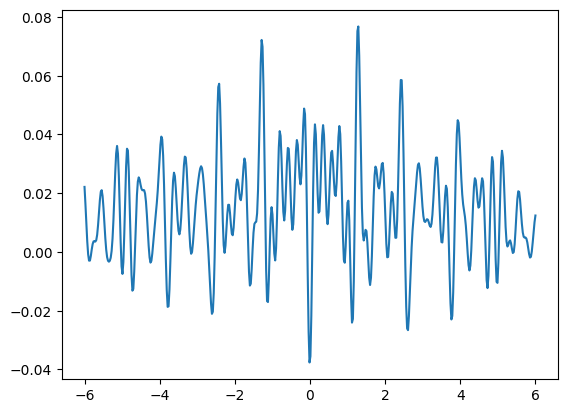

In [34]:
x_dist,xaxis = shors.momentum_plotting(rho_qumode_0,cutoff, ax_min=-6, ax_max=6)
display(plt.plot(xaxis,x_dist.flatten()))

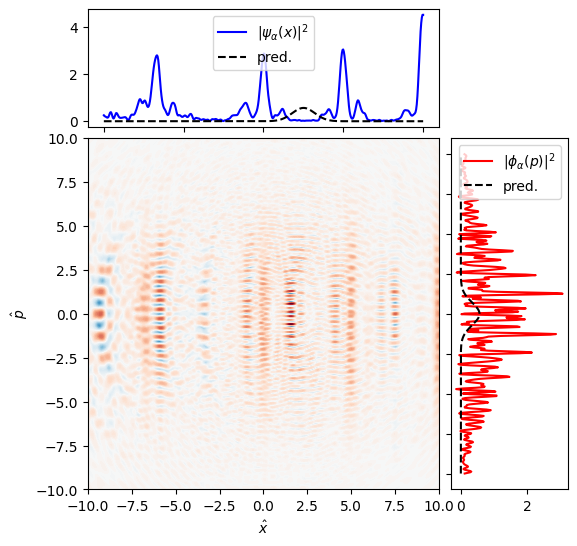

In [20]:
#This cell is mostly plotting
w = c2qa.wigner.wigner(rho_qumode_0, axes_max= 10, axes_min= -10, axes_steps = 500)
x_dist, y_dist = margins(w.T)

fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2,  width_ratios=(3, 1), height_ratios=(1, 3),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1,0])
ax_x = fig.add_subplot(gs[0,0])
ax_y = fig.add_subplot(gs[1,1])

absmax = max(np.max(w), np.abs(np.min(w)))
color_levels = np.linspace(-absmax, absmax, 100)

#Plot the wigner function of the coherent state in the main panel with a colormap
xaxis = np.linspace(-10, 10, 500)
yaxis = np.linspace(-10, 10, 500)
cont = ax.contourf(xaxis, yaxis, w, color_levels, cmap = "RdBu_r")

#compute the expected means and variance of the two distributions
mux = np.sqrt(2)*np.real(alpha)
muy = np.sqrt(2)*np.imag(alpha)
sigma = .5

#plot the distributions against the (normalized) marginals of the wigner function
ax_x.plot(xaxis, x_dist,  label = r"$|\psi_\alpha(x)|^2$", c= "b")
ax_x.plot(xaxis, 1/np.sqrt(2*np.pi*sigma)*np.exp(-(xaxis-mux)**2/(2*sigma)), c ="k", linestyle = "--", label="pred.")

ax_y.plot(y_dist.T, yaxis, label = r"$|\phi_\alpha(p)|^2$", c = "r")
ax_y.plot(1/np.sqrt(2*np.pi*sigma)*np.exp(-(yaxis-muy)**2/(2*sigma)), yaxis, c="k", linestyle = "--", label = "pred.")

ax.set(xlabel=r"$\hat x$", ylabel=r"$\hat p$")
ax_x.legend()
ax_y.legend()
ax_x.set_xticklabels([]);
ax_y.set_yticklabels([]);

## Final Circuit

In [ ]:
from fractions import Fraction
from math import gcd

def continued_fraction_candidates(p_meas, max_denominator=100):
    s_over_r = p_meas 
    frac = Fraction(s_over_r).limit_denominator(max_denominator)
    j, r = frac.numerator, frac.denominator

    if gcd(j, r) == 1:
        return r, (j, r)
    else:
        return None, (j, r)
    

def estimate_period_with_cf(p_dist, paxis, min_prominence=0.05, max_denominator=100):
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(p_dist, prominence=min_prominence)
    peak_positions = paxis[peaks]

    candidates = []
    for p in peak_positions:
        r, (j, denom) = continued_fraction_candidates(p, max_denominator=max_denominator)
        if r is not None:
            candidates.append(r)

    if not candidates:
        print("No valid period candidates found.")
        return None, peak_positions
    from collections import Counter
    most_common_r = Counter(candidates).most_common(1)[0][0]

    return most_common_r, peak_positions

In [4]:
def try_find_factors(N, r, a):
    if r % 2 != 0:
        return None
    candidate = pow(a, r//2, N)
    if candidate == N-1 or candidate == 1:
        return None
    p = np.gcd(candidate-1, N)
    q = np.gcd(candidate+1, N)
    if p*q == N and p != 1 and q != 1:
        return (p, q)
    else:
        return None
    
def find_valid_a_values(N):
    valid_a = []
    for a in range(2, N):
        if gcd(a, N) != 1:
            continue
        r = 1
        while pow(a, r, N) != 1 and r < N:
            r += 1
        if r % 2 == 0 and pow(a, r // 2, N) != N - 1:
            valid_a.append((a, r))
    return valid_a

In [ ]:
def estimate_success_probability_for_all_a(N, m, R, delta, cutoff, N_rounds=9, trials=20):
    best_success = 0
    best_a = None

    results = []

    for a, true_r in find_valid_a_values(N):
        print(f"\nTrying a = {a}, expected period = {true_r}")
        success_count = 0
        alpha = np.sqrt(np.pi)

        for trial in range(trials):
            circuit = c2qa.CVCircuit(qmr1, qbr, cr)

            for i in range(3):
                circuit.cv_sq(-np.log(delta), qmr1[i])

            for k in range(1, N_rounds):
                circuit.cv_c_d(alpha, qmr1[0], qbr[0])
                Uxk = state_generation.Ux_operator(cutoff, alpha, 4 * k, delta)
                Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
                circuit.append(Ux_gate, qmr1[0] + qbr[:])

            for k in range(1, N_rounds):
                circuit.cv_c_d(alpha, qmr1[1], qbr[0])
                Uxk = state_generation.Ux_operator(cutoff, alpha, 4 * k, delta)
                Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
                circuit.append(Ux_gate, qmr1[1] + qbr[:])

            R_displace = shors.translation_R(cutoff, R)
            circuit.append(UnitaryGate(R_displace.full(), label='R'), qmr1[0])
            Malpha = shors.multiplication(cutoff, N)
            circuit.append(UnitaryGate(Malpha.full(), label=f'M{N}'), qmr1[1])
            circuit = shors.U_aNm(cutoff, circuit, qmr1, qbr, a, N, m)

            stateop, result, _ = c2qa.util.simulate(circuit, shots=1)
            rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)
            x_dist, xaxis = shors.momentum_plotting(rho_qumode_0, cutoff, ax_min=-30, ax_max=30)

            estimated_r, peaks = estimate_period_with_cf(x_dist.flatten(),xaxis)
            print(f"\n estimated period = {estimated_r}")
            factors = try_find_factors(N, estimated_r, a)
            if factors is not None:
                print(f"Trial {trial + 1}: Found factors {factors}")
                success_count += 1
            plt.figure(figsize=(10, 4))
            plt.plot(xaxis, x_dist.flatten(), label='Momentum Distribution')
            plt.title(f"Momentum distribution (Trial {trial+1})")
            plt.xlabel("p (momentum)")
            plt.ylabel("Probability")
            plt.grid(True)

            for px in peaks:
                plt.axvline(px, color='r', linestyle='--', alpha=0.7)
                frac = Fraction(px / (2 * np.pi)).limit_denominator(100)
                r_approx = frac.denominator
                label = f'{frac.numerator}/{frac.denominator} → r={r_approx}'
                plt.text(px, 0.01, label, rotation=90, fontsize=8, verticalalignment='bottom')

            plt.legend()
            plt.tight_layout()
            plt.show()

        success_rate = success_count / trials
        results.append((a, success_rate))
        print(f"Success rate for a = {a}: {success_count}/{trials} = {success_rate:.2f}")

        if success_rate > best_success:
            best_success = success_rate
            best_a = a

    print("\n--- Summary ---")
    for a, rate in results:
        print(f"a = {a} → success rate = {rate:.2f}")
    print(f"\nBest a: {best_a} with success probability {best_success:.2f}")
    return best_a, best_success, results


Trying a = 5, expected period = 10
31
25
5
⟨p⟩ = -0.3115369711319492

 estimated period = 71


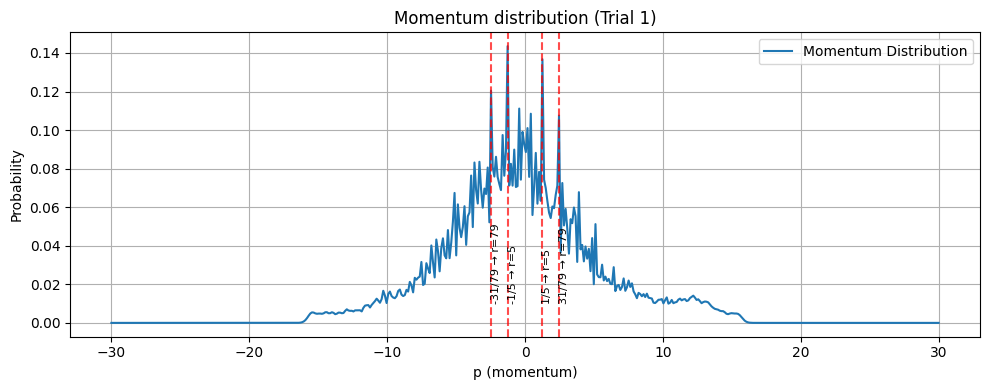

Success rate for a = 5: 0/1 = 0.00

Trying a = 7, expected period = 10
25
16
7
⟨p⟩ = -0.30918614802570876

 estimated period = 71


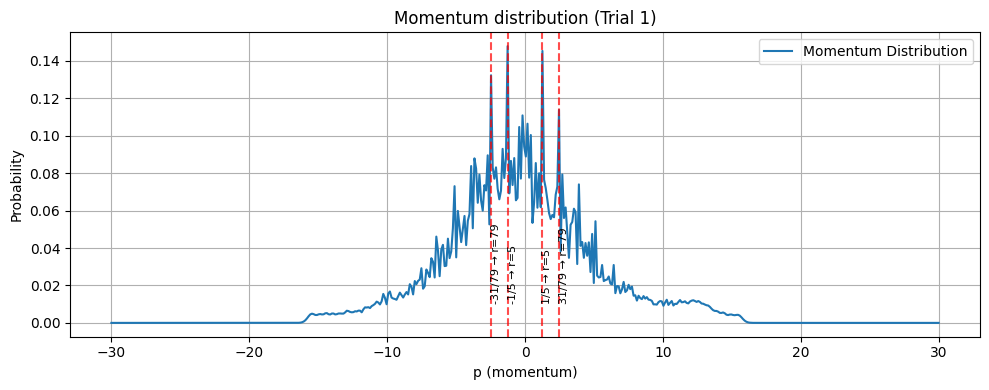

Success rate for a = 7: 0/1 = 0.00

Trying a = 10, expected period = 2
1
1
10
⟨p⟩ = -1.5822117290452432e-14

 estimated period = 100


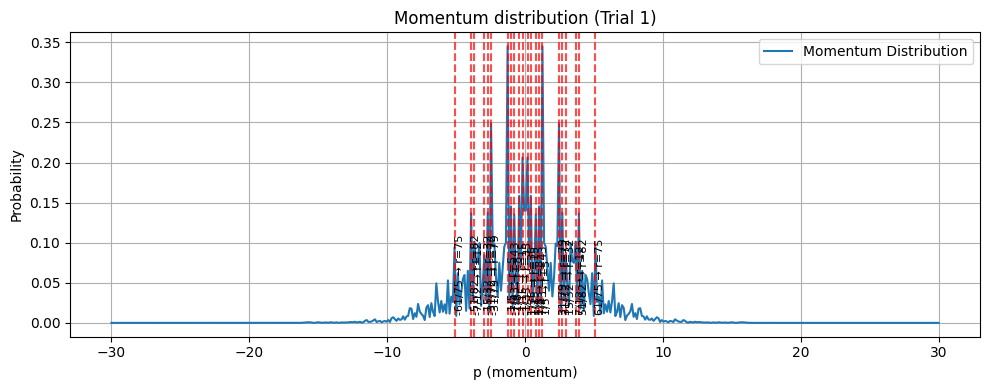

Success rate for a = 10: 0/1 = 0.00

Trying a = 13, expected period = 10
16
4
13
⟨p⟩ = -0.30195494111092513

 estimated period = 71


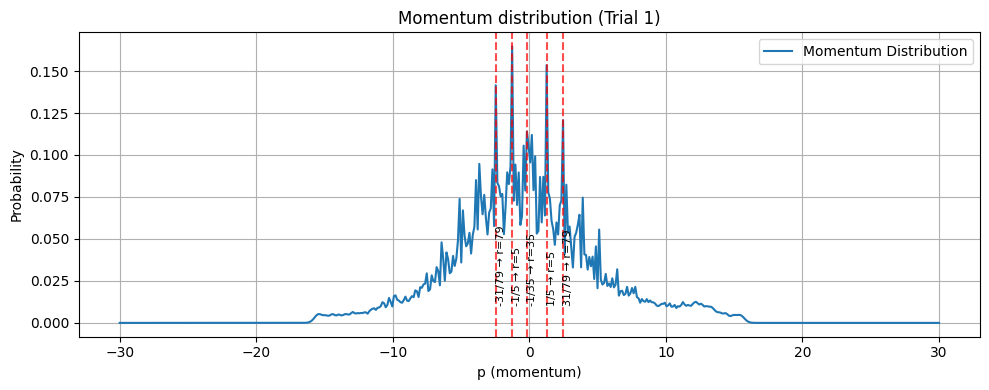

Success rate for a = 13: 0/1 = 0.00

Trying a = 14, expected period = 10
4
31
14


In [ ]:
best_a, best_prob, all_results = estimate_success_probability_for_all_a(
    N=33, m=3, R=15, delta=0.222, cutoff=128, N_rounds=9, trials=1
)